# FF-SNN MNIST Model Comparison

This notebook compares the four FF-SNN neuron models trained on MNIST:

- `lif`
- `alif`
- `srm`
- `dynsrm`

It is designed for publication-style analysis and figure generation. The workflow:

- auto-discovers the latest run CSV for each model
- builds final and best-epoch comparison tables
- plots optimization dynamics and efficiency trade-offs
- compares normalized confusion matrices

The figure styling follows a scientific-journal aesthetic with serif fonts, restrained color choices, compact layouts, and high-resolution export.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RESULT_ROOT = Path('/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers')
NOTEBOOK_DIR = RESULT_ROOT.parent.parent
FIGURE_DIR = NOTEBOOK_DIR / 'figures_journal'
FIGURE_DIR.mkdir(exist_ok=True)

MODEL_ORDER = ['lif', 'alif', 'srm', 'dynsrm']
MODEL_LABELS = {
    'lif': 'LIF',
    'alif': 'ALIF',
    'srm': 'SRM',
    'dynsrm': 'Dynamic SRM',
}
MODEL_COLORS = {
    'lif': '#1f3b73',
    'alif': '#3c8d5a',
    'srm': '#b35c1e',
    'dynsrm': '#7b3f98',
}

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 400,
    'figure.figsize': (6.2, 4.2),
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.25,
    'lines.linewidth': 2.0,
    'lines.markersize': 5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
sns.set_theme(style='whitegrid', context='paper')

CSV_PATTERN = re.compile(r'MNIST_(lif|alif|srm|dynsrm)_FF_v2_(\d{8}_\d{6})\.csv$')


def discover_latest_runs(result_root: Path):
    latest = {}
    for model in MODEL_ORDER:
        model_dir = result_root / model
        if not model_dir.exists():
            continue
        for csv_path in model_dir.glob('MNIST_*_FF_v2_*.csv'):
            match = CSV_PATTERN.match(csv_path.name)
            if match is None:
                continue
            _, timestamp = match.groups()
            prev = latest.get(model)
            if prev is None or timestamp > prev['timestamp']:
                latest[model] = {'timestamp': timestamp, 'path': csv_path}
    missing = [model for model in MODEL_ORDER if model not in latest]
    if missing:
        raise FileNotFoundError(f'Missing result CSVs for: {missing}')
    return {model: latest[model]['path'] for model in MODEL_ORDER}


def resolve_artifact_path(path_value: str, run_csv_path: Path) -> Path:
    candidate = Path(path_value)
    if candidate.is_absolute() and candidate.exists():
        return candidate

    direct_candidate = (run_csv_path.parent / candidate.name).resolve()
    if direct_candidate.exists():
        return direct_candidate

    nested_candidate = (NOTEBOOK_DIR / candidate).resolve()
    if nested_candidate.exists():
        return nested_candidate

    matches = list(run_csv_path.parent.glob(candidate.name))
    if matches:
        return matches[0]

    raise FileNotFoundError(f'Could not resolve artifact path: {path_value}')


def load_runs():
    run_paths = discover_latest_runs(RESULT_ROOT)
    runs = {}
    for model, path in run_paths.items():
        df = pd.read_csv(path).sort_values('epoch').reset_index(drop=True)
        df['model'] = model
        df['model_label'] = MODEL_LABELS[model]
        df['relative_progress'] = df['epoch'] / df['epoch'].max()
        df['run_csv_path'] = str(path)

        for artifact_col in [
            'best_test_confusion_path',
            'final_test_confusion_path',
            'best_model_path',
            'final_model_path',
        ]:
            if artifact_col in df.columns:
                df[artifact_col] = df[artifact_col].apply(lambda value: str(resolve_artifact_path(value, path)) if isinstance(value, str) and value else value)

        runs[model] = df
    return run_paths, runs


def best_epoch_row(df: pd.DataFrame, metric: str = 'test_macro_f1') -> pd.Series:
    idx = df[metric].idxmax()
    return df.loc[idx]


def load_confusion(path_value: str) -> pd.DataFrame:
    return pd.read_csv(Path(path_value), index_col=0)


def normalize_confusion(df: pd.DataFrame) -> pd.DataFrame:
    values = df.to_numpy(dtype=float)
    row_sums = values.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return pd.DataFrame(values / row_sums, index=df.index, columns=df.columns)


def panel_label(ax, label):
    ax.text(-0.16, 1.06, label, transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')


run_paths, runs = load_runs()
print('Loaded result files from result/2layers/<model>:')
for model, path in run_paths.items():
    print(f'  {model:7s} -> {path}')

Loaded result files from result/2layers/<model>:
  lif     -> /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/lif/MNIST_lif_FF_v2_20260324_113036.csv
  alif    -> /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/alif/MNIST_alif_FF_v2_20260324_113459.csv
  srm     -> /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/srm/MNIST_srm_FF_v2_20260407_161734.csv
  dynsrm  -> /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/result/2layers/dynsrm/MNIST_dynsrm_FF_v2_20260407_155024.csv


In [2]:
summary_rows = []
for model, df in runs.items():
    final_row = df.iloc[-1]
    best_row = best_epoch_row(df, metric='test_macro_f1')
    summary_rows.append({
        'model': MODEL_LABELS[model],
        'epochs_trained': int(df['epoch'].max()),
        'best_epoch_by_f1': int(best_row['epoch']),
        'best_test_acc': float(best_row['test_acc']),
        'best_test_f1': float(best_row['test_macro_f1']),
        'final_test_acc': float(final_row['test_acc']),
        'final_test_f1': float(final_row['test_macro_f1']),
        'best_test_latency_ms': float(best_row['test_latency_ms_per_sample']),
        'best_test_spike_rate': float(best_row['test_global_spike_rate']),
        'best_event_synops': float(best_row['test_event_synops']),
        'best_event_to_dense_ratio': float(best_row['test_event_to_dense_ratio']),
        'final_test_speed': float(final_row['test_speed']),
        'final_test_cpu_memory_mb': float(final_row['test_cpu_memory_mb']),
        'final_test_gpu_memory_mb': float(final_row['test_gpu_memory_allocated_mb']),
        'csv_path': str(run_paths[model]),
        'best_model_path': str(best_row['best_model_path']),
        'final_model_path': str(final_row['final_model_path']),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('best_test_f1', ascending=False).reset_index(drop=True)
comparison_csv = FIGURE_DIR / 'ff_model_comparison_summary.csv'
summary_df.to_csv(comparison_csv, index=False)

pd.options.display.float_format = '{:,.4f}'.format
display(summary_df)
print(f'Saved summary table to: {comparison_csv}')

,model,epochs_trained,best_epoch_by_f1,best_test_acc,best_test_f1,final_test_acc,final_test_f1,best_test_latency_ms,best_test_spike_rate,best_event_synops,best_event_to_dense_ratio,final_test_speed,final_test_cpu_memory_mb,final_test_gpu_memory_mb,csv_path,best_model_path,final_model_path
0,SRM,100,78,0.9799,0.9797,0.9781,0.9780,0.4961,0.0131,"78,932,850,000.0000",0.1229,"1,656.4678","1,517.1523",840.3784,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...
1,Dynamic SRM,100,97,0.9789,0.9788,0.9784,0.9783,0.6622,0.0132,"78,922,514,500.0000",0.1229,"1,336.3089","1,522.1016",840.0815,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...
2,ALIF,100,99,0.9757,0.9755,0.9738,0.9736,0.1831,0.0016,"76,530,056,500.0000",0.1192,"4,673.2802","1,479.6133",418.9941,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...
3,LIF,100,87,0.9731,0.9728,0.9710,0.9707,0.3662,0.0013,"76,434,631,000.0000",0.1191,"2,866.0107","1,482.5977",421.2266,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...,/home/yhxu/spikingjelly/spikingjelly/spikingje...


Saved summary table to: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/figures_journal/ff_model_comparison_summary.csv


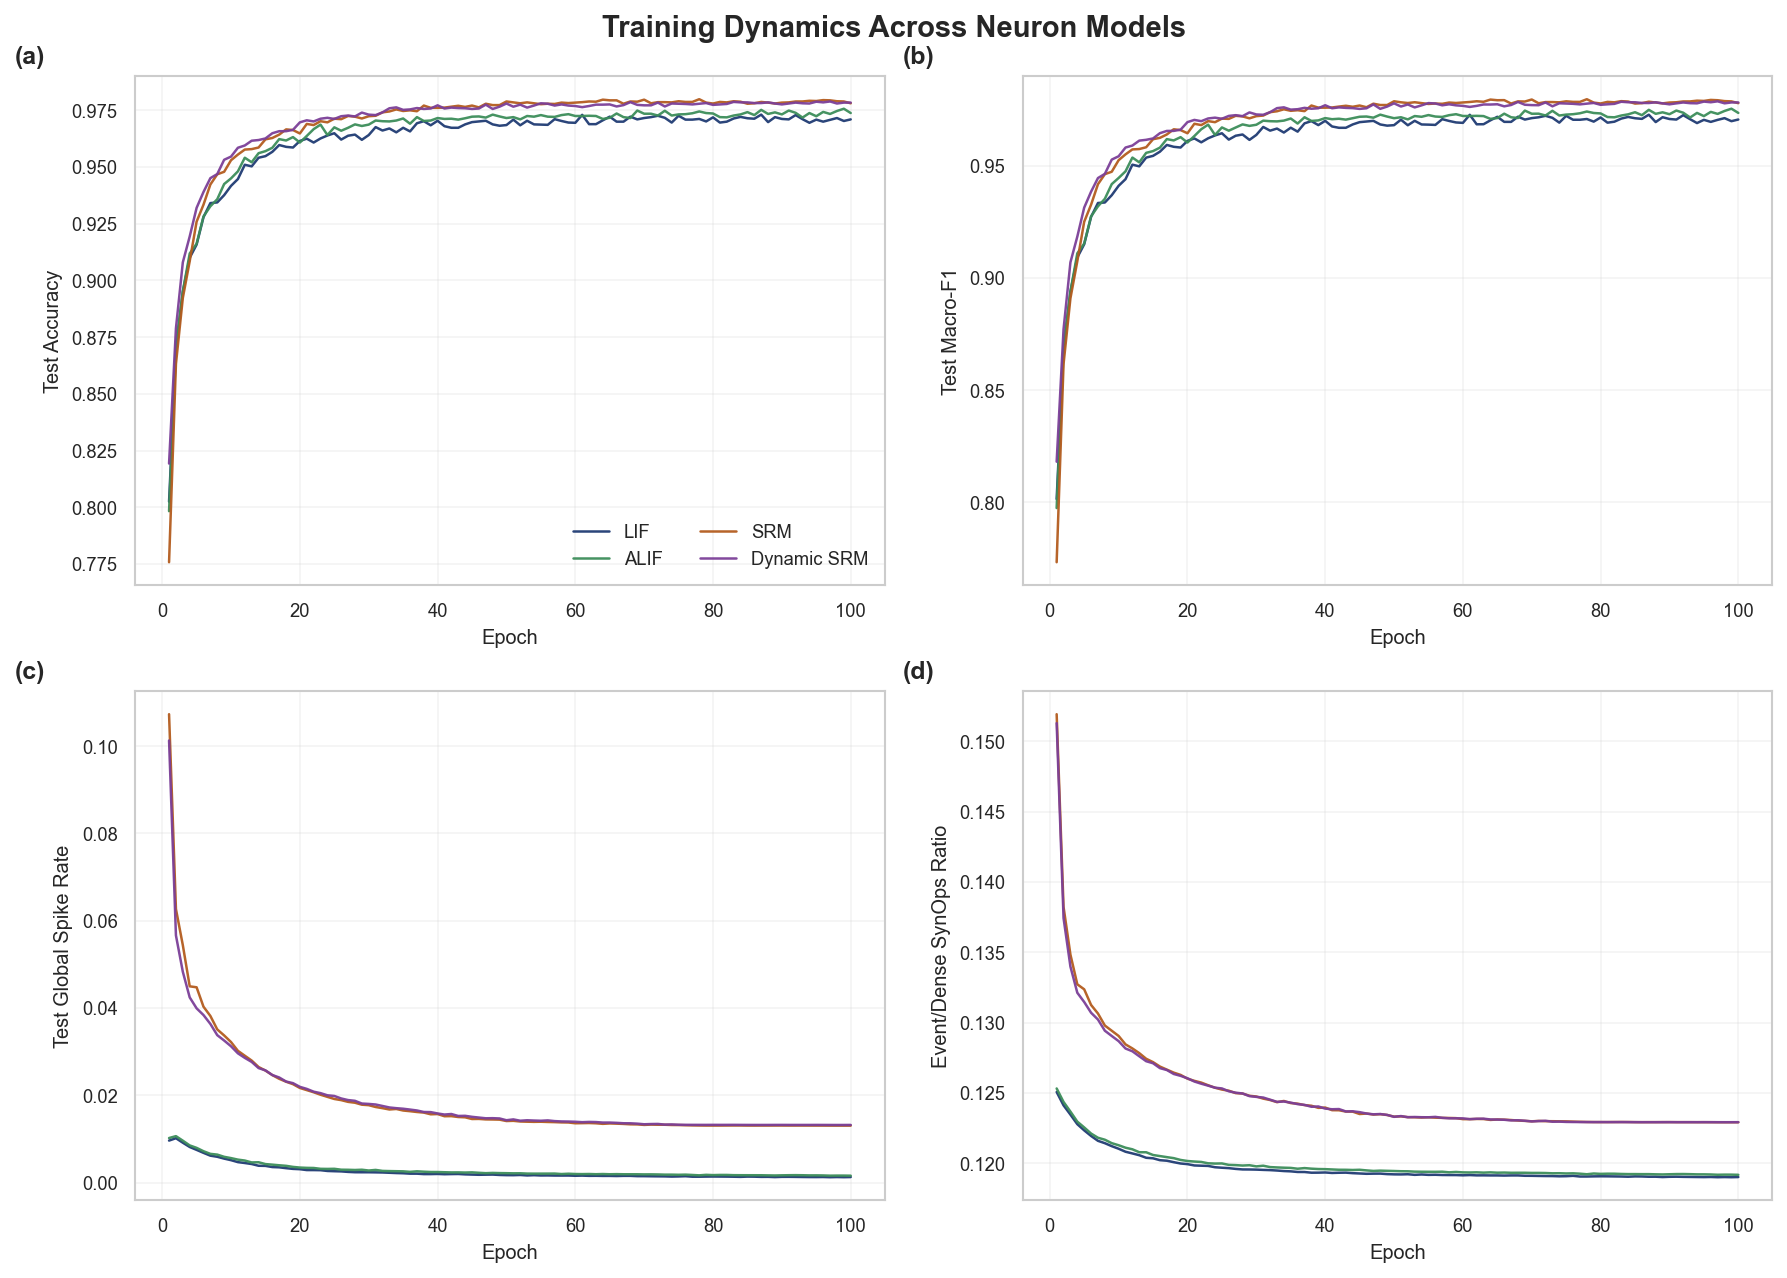

Saved figure to: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/figures_journal/ff_training_dynamics_journal.png


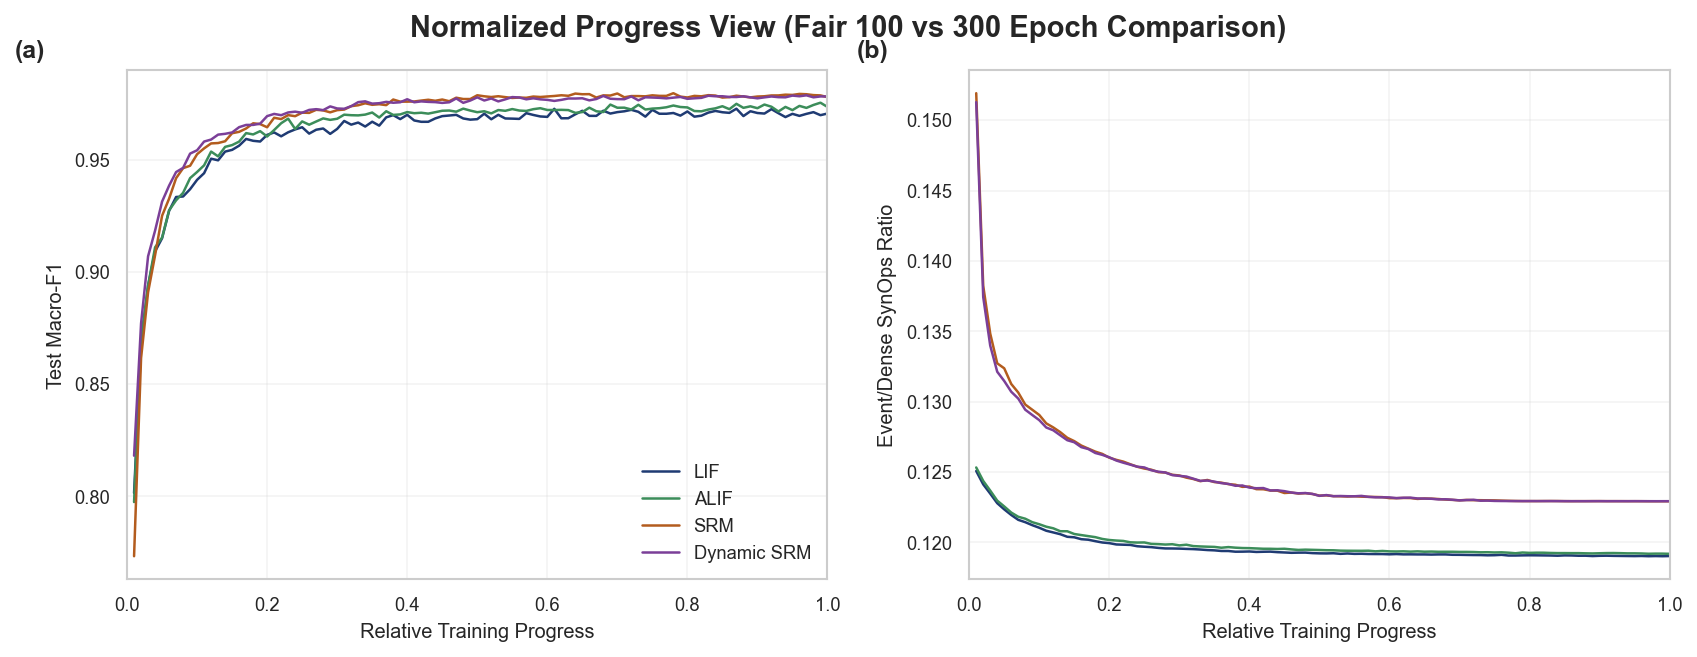

Saved figure to: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/figures_journal/ff_normalized_progress_journal.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11.8, 8.2), constrained_layout=True)
metric_specs = [
    ('test_acc', 'Test Accuracy', '(a)'),
    ('test_macro_f1', 'Test Macro-F1', '(b)'),
    ('test_global_spike_rate', 'Test Global Spike Rate', '(c)'),
    ('test_event_to_dense_ratio', 'Event/Dense SynOps Ratio', '(d)'),
]

for ax, (metric, ylabel, label) in zip(axes.ravel(), metric_specs):
    for model in MODEL_ORDER:
        df = runs[model]
        ax.plot(
            df['epoch'],
            df[metric],
            color=MODEL_COLORS[model],
            label=MODEL_LABELS[model],
            alpha=0.95,
        )
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.grid(True, which='major', alpha=0.22)
    panel_label(ax, label)

axes[0, 0].legend(frameon=False, ncol=2, loc='lower right')
fig.suptitle('Training Dynamics Across Neuron Models', y=1.02, fontsize=14, fontweight='bold')
training_path = FIGURE_DIR / 'ff_training_dynamics_journal.png'
fig.savefig(training_path, bbox_inches='tight')
plt.show()
print(f'Saved figure to: {training_path}')

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.1), constrained_layout=True)
normalized_specs = [
    ('test_macro_f1', 'Test Macro-F1', '(a)'),
    ('test_event_to_dense_ratio', 'Event/Dense SynOps Ratio', '(b)'),
]

for ax, (metric, ylabel, label) in zip(axes, normalized_specs):
    for model in MODEL_ORDER:
        df = runs[model]
        ax.plot(
            df['relative_progress'],
            df[metric],
            color=MODEL_COLORS[model],
            label=MODEL_LABELS[model],
        )
    ax.set_xlabel('Relative Training Progress')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 1.0)
    ax.grid(True, which='major', alpha=0.22)
    panel_label(ax, label)

axes[0].legend(frameon=False, loc='lower right')
fig.suptitle('Normalized Progress View (Fair 100 vs 300 Epoch Comparison)', y=1.03, fontsize=14, fontweight='bold')
normalized_path = FIGURE_DIR / 'ff_normalized_progress_journal.png'
fig.savefig(normalized_path, bbox_inches='tight')
plt.show()
print(f'Saved figure to: {normalized_path}')

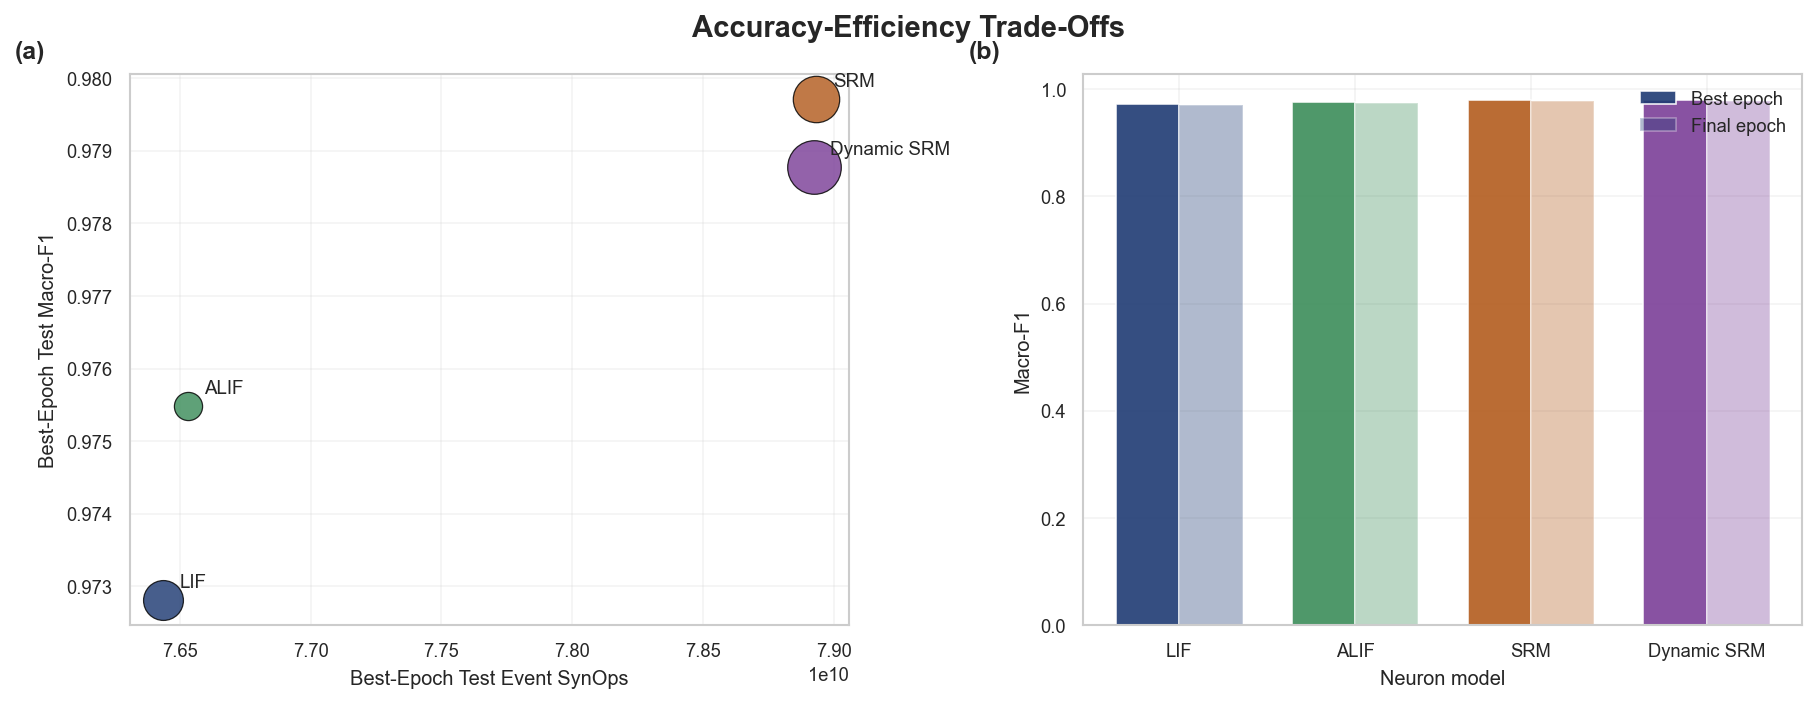

Saved figure to: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/figures_journal/ff_tradeoff_journal.png


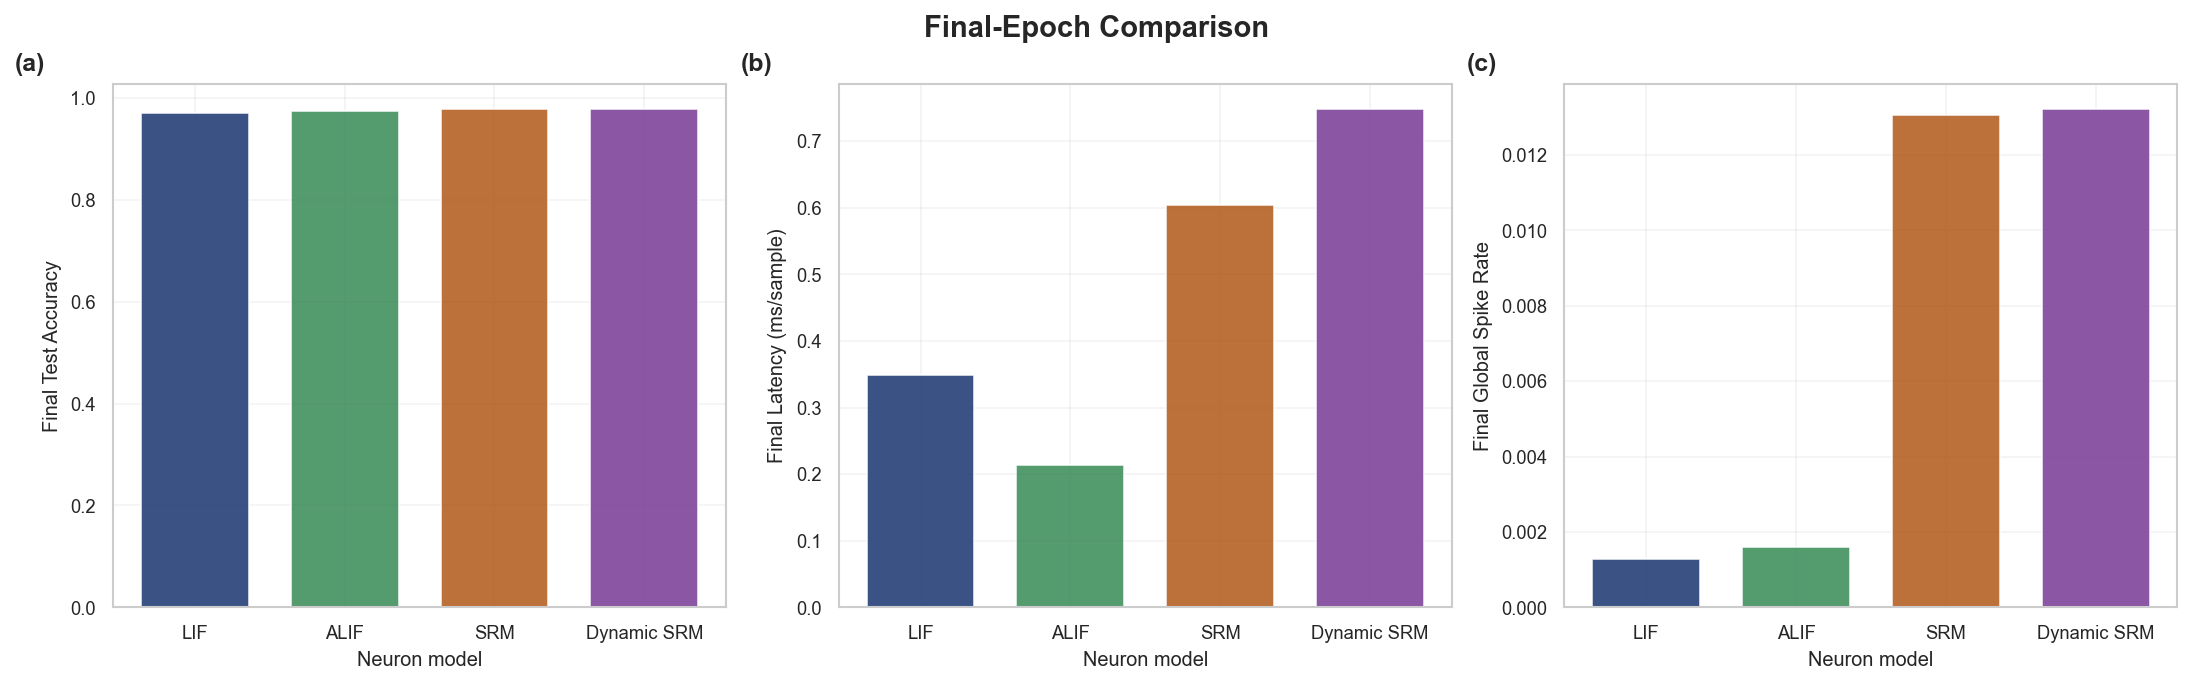

Saved figure to: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/figures_journal/ff_final_epoch_comparison_journal.png


In [4]:
best_rows = {model: best_epoch_row(df, metric='test_macro_f1') for model, df in runs.items()}
final_rows = {model: df.iloc[-1] for model, df in runs.items()}

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), constrained_layout=True)

ax = axes[0]
for model in MODEL_ORDER:
    row = best_rows[model]
    ax.scatter(
        row['test_event_synops'],
        row['test_macro_f1'],
        s=1000 * row['test_latency_ms_per_sample'],
        color=MODEL_COLORS[model],
        alpha=0.82,
        edgecolor='black',
        linewidth=0.6,
        label=MODEL_LABELS[model],
    )
    ax.annotate(
        MODEL_LABELS[model],
        (row['test_event_synops'], row['test_macro_f1']),
        textcoords='offset points',
        xytext=(8, 6),
        fontsize=9,
    )
ax.set_xlabel('Best-Epoch Test Event SynOps')
ax.set_ylabel('Best-Epoch Test Macro-F1')
ax.grid(True, alpha=0.22)
panel_label(ax, '(a)')

ax = axes[1]
bar_models = [MODEL_LABELS[m] for m in MODEL_ORDER]
x = np.arange(len(MODEL_ORDER))
width = 0.36
best_f1 = [best_rows[m]['test_macro_f1'] for m in MODEL_ORDER]
final_f1 = [final_rows[m]['test_macro_f1'] for m in MODEL_ORDER]
ax.bar(x - width / 2, best_f1, width=width, color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.90, label='Best epoch')
ax.bar(x + width / 2, final_f1, width=width, color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.35, label='Final epoch')
ax.set_xticks(x)
ax.set_xticklabels(bar_models, rotation=0)
ax.set_ylabel('Macro-F1')
ax.set_xlabel('Neuron model')
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.22)
panel_label(ax, '(b)')

fig.suptitle('Accuracy-Efficiency Trade-Offs', y=1.03, fontsize=14, fontweight='bold')
tradeoff_path = FIGURE_DIR / 'ff_tradeoff_journal.png'
fig.savefig(tradeoff_path, bbox_inches='tight')
plt.show()
print(f'Saved figure to: {tradeoff_path}')

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), constrained_layout=True)
bar_metrics = [
    ('test_acc', 'Final Test Accuracy', '(a)'),
    ('test_latency_ms_per_sample', 'Final Latency (ms/sample)', '(b)'),
    ('test_global_spike_rate', 'Final Global Spike Rate', '(c)'),
]
for ax, (metric, ylabel, label) in zip(axes, bar_metrics):
    values = [final_rows[m][metric] for m in MODEL_ORDER]
    ax.bar(bar_models, values, color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.88, width=0.72)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Neuron model')
    ax.grid(True, axis='y', alpha=0.22)
    panel_label(ax, label)

fig.suptitle('Final-Epoch Comparison', y=1.05, fontsize=14, fontweight='bold')
final_bar_path = FIGURE_DIR / 'ff_final_epoch_comparison_journal.png'
fig.savefig(final_bar_path, bbox_inches='tight')
plt.show()
print(f'Saved figure to: {final_bar_path}')

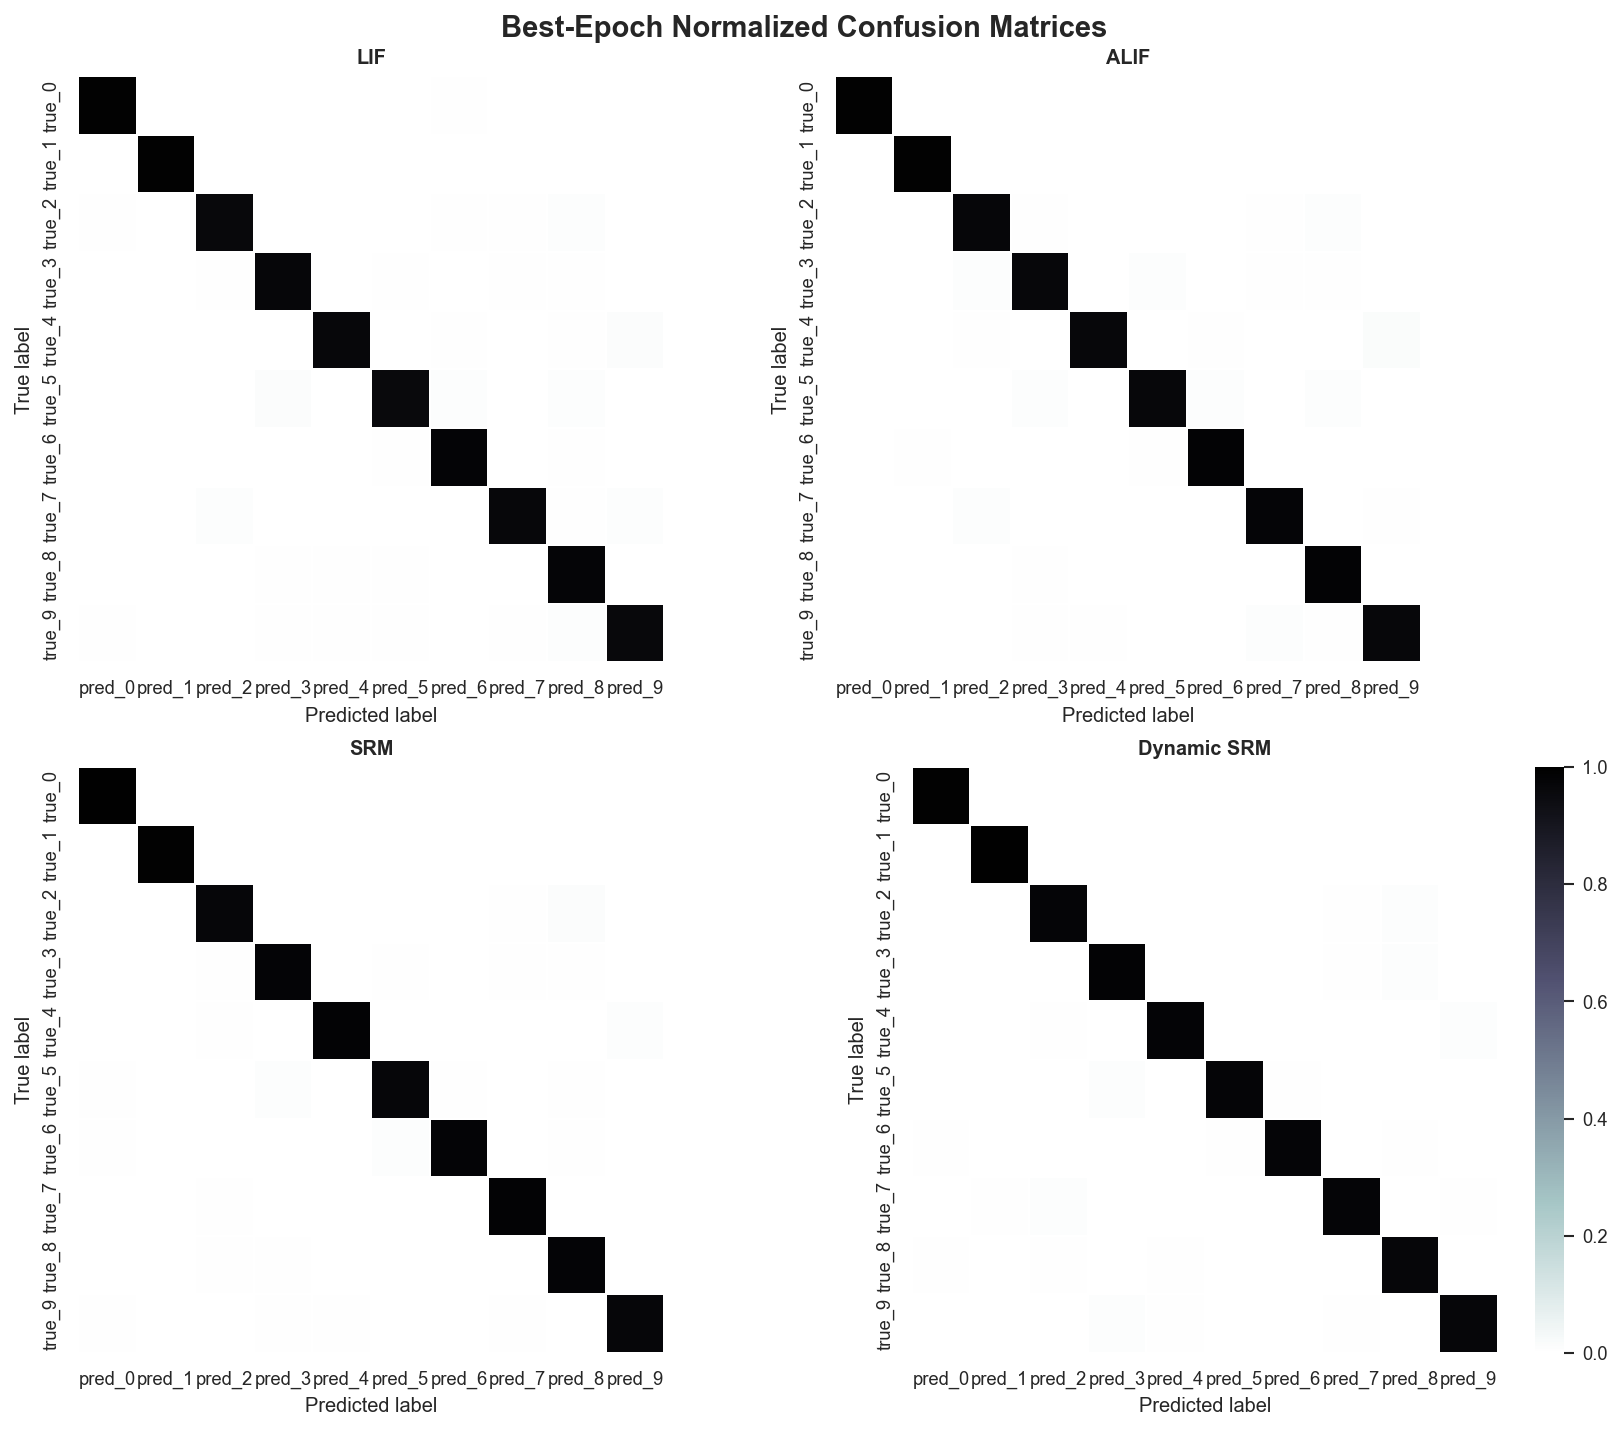

Saved figure to: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/MNIST/v2/figures_journal/ff_confusion_matrices_journal.png


,model,best_f1,best_acc,latency_ms,spike_rate,event_to_dense
0,SRM,0.9797,0.9799,0.4961,0.0131,0.1229
1,Dynamic SRM,0.9788,0.9789,0.6622,0.0132,0.1229
2,ALIF,0.9755,0.9757,0.1831,0.0016,0.1192
3,LIF,0.9728,0.9731,0.3662,0.0013,0.1191


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10.8, 9.2), constrained_layout=True)
axes = axes.ravel()

for ax, model in zip(axes, MODEL_ORDER):
    best_row = best_rows[model]
    confusion_df = load_confusion(best_row['best_test_confusion_path'])
    confusion_norm = normalize_confusion(confusion_df)
    sns.heatmap(
        confusion_norm,
        ax=ax,
        cmap='bone_r',
        vmin=0.0,
        vmax=1.0,
        cbar=(model == MODEL_ORDER[-1]),
        square=True,
        linewidths=0.2,
        linecolor='white',
    )
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

fig.suptitle('Best-Epoch Normalized Confusion Matrices', y=1.02, fontsize=14, fontweight='bold')
confusion_path = FIGURE_DIR / 'ff_confusion_matrices_journal.png'
fig.savefig(confusion_path, bbox_inches='tight')
plt.show()
print(f'Saved figure to: {confusion_path}')

ranked = summary_df[['model', 'best_test_f1', 'best_test_acc', 'best_test_latency_ms', 'best_test_spike_rate', 'best_event_to_dense_ratio']].copy()
ranked = ranked.rename(columns={
    'best_test_f1': 'best_f1',
    'best_test_acc': 'best_acc',
    'best_test_latency_ms': 'latency_ms',
    'best_test_spike_rate': 'spike_rate',
    'best_event_to_dense_ratio': 'event_to_dense',
})
display(ranked)

## Notes For Interpretation

- `best_test_f1` is the most robust single headline metric for balanced comparison across the four models.
- `test_event_synops` and `test_event_to_dense_ratio` are efficiency proxies rather than physical energy measurements; they are still useful for relative cross-model comparison.
- Because `lif` and `alif` were trained for 100 epochs while `srm` and `dynsrm` were trained for 300 epochs, the normalized-progress figure is important for fairness.
- The confusion matrices use row normalization, which makes class-specific failure modes easier to compare visually.

If needed, this notebook can be extended later to compare FF vs BP runs in the same figure set.